# 04 - EDA Summary and Feature Engineering Plan

## Business Question
> Berdasarkan hasil EDA harian, mingguan, dan output rekomendasi, fitur apa saja yang perlu dipertahankan, direkayasa, atau dikeluarkan sebelum membentuk dataset modelling final?

## Sub-Business Questions
- Fitur apa yang paling konsisten berkorelasi dengan stress_score?
- Fitur apa yang memiliki potensi data leakage?
- Feature engineering apa yang paling relevan berdasarkan hasil EDA?
- Apakah seluruh fitur numerik layak digunakan untuk modelling?
- Fitur mana yang lebih cocok dijadikan fitur agregasi atau kategori?
- Bagaimana struktur final modelling dataset yang paling optimal?

# 0. Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

OUTPUT_REPORTS = '../../../outputs/reports/'
OUTPUT_FIGURES = '../../../outputs/figures/eda/'

import os
os.makedirs(OUTPUT_REPORTS, exist_ok=True)
os.makedirs(OUTPUT_FIGURES, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


# 1. Load Data 

In [2]:
# --- Dari 01_daily_stress_eda ---
daily_corr       = pd.read_csv(OUTPUT_REPORTS + 'daily_feature_correlation_with_stress_score.csv')
daily_summary    = pd.read_csv(OUTPUT_REPORTS + 'daily_feature_summary_by_stress_level.csv')
daily_importance = pd.read_csv(OUTPUT_REPORTS + 'daily_feature_importance_baseline.csv')

# --- Dari 02_weekly_stress_eda ---
weekly_corr    = pd.read_csv(OUTPUT_REPORTS + 'weekly_feature_correlation_with_average_stress_score.csv')
weekly_trend   = pd.read_csv(OUTPUT_REPORTS + 'weekly_stress_trend_summary.csv')
weekly_trigger = pd.read_csv(OUTPUT_REPORTS + 'weekly_main_trigger_counts.csv')

# --- Dari 03_recommendation_output_eda ---
rec_category = pd.read_csv(OUTPUT_REPORTS + 'recommendation_category_counts.csv')
rec_priority = pd.read_csv(OUTPUT_REPORTS + 'recommendation_category_by_priority.csv')

print('Semua report berhasil di-load.')

Semua report berhasil di-load.


# 2. Ringkasan Insight Daily EDA (01_daily_stress_eda)

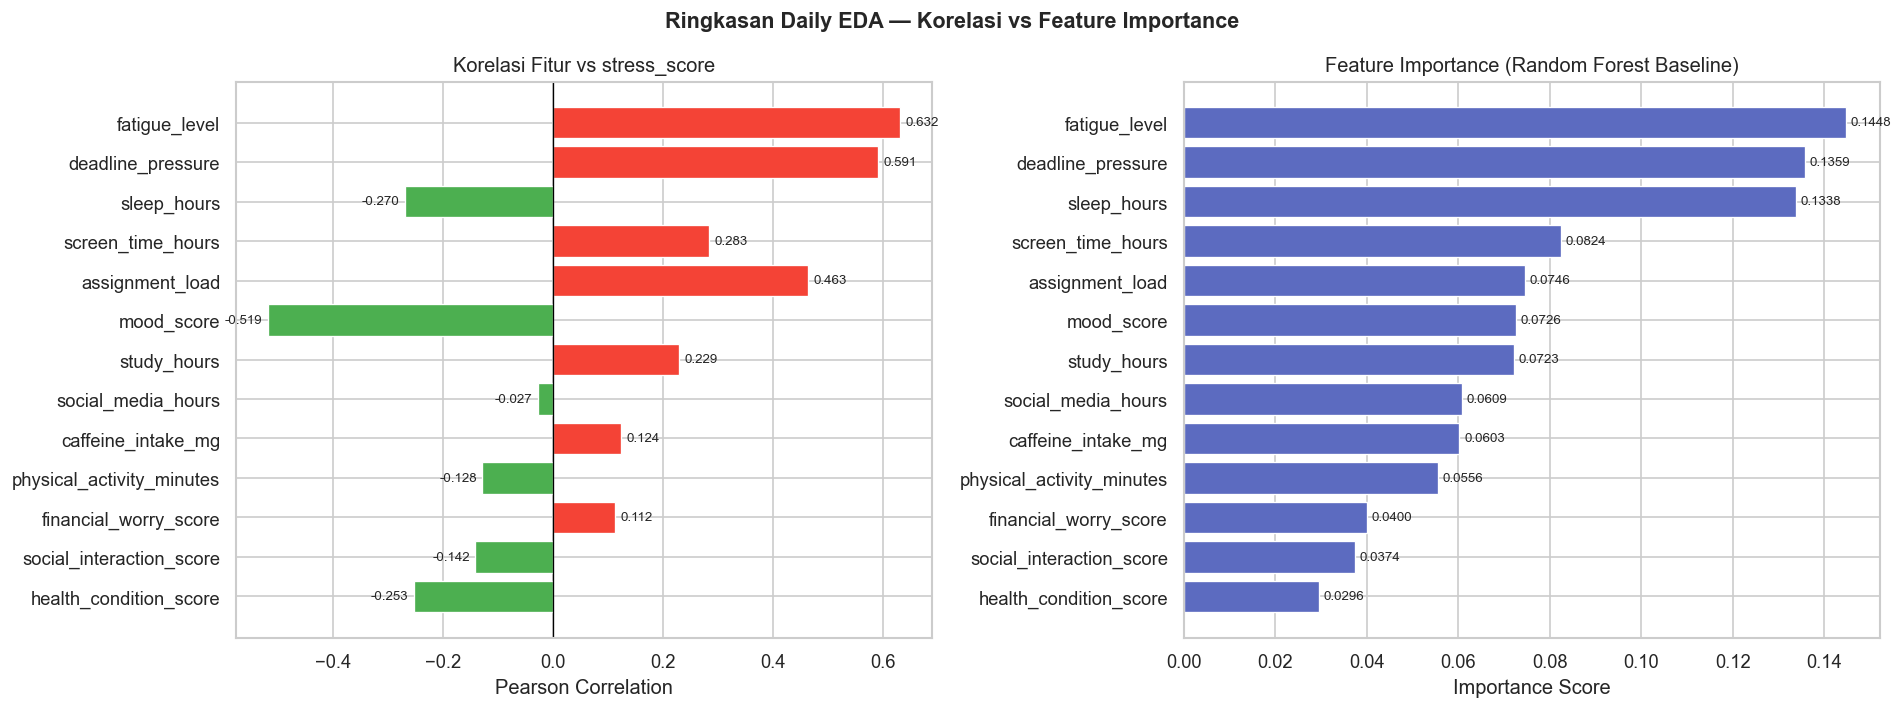

In [3]:
# Merge korelasi dan importance untuk perbandingan
daily_corr_sorted = daily_corr.set_index('feature')['correlation_with_stress_score']
daily_imp_sorted  = daily_importance.set_index('feature')['importance']

compare_df = pd.DataFrame({
    'Korelasi dengan stress_score': daily_corr_sorted,
    'Feature Importance (RF)'     : daily_imp_sorted
}).sort_values('Feature Importance (RF)', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ringkasan Daily EDA — Korelasi vs Feature Importance', fontsize=13, fontweight='bold')

# Korelasi
colors_corr = ['#F44336' if v > 0 else '#4CAF50' for v in compare_df['Korelasi dengan stress_score']]
axes[0].barh(compare_df.index, compare_df['Korelasi dengan stress_score'],
             color=colors_corr, edgecolor='white', linewidth=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Korelasi Fitur vs stress_score')
axes[0].set_xlabel('Pearson Correlation')
for i, (idx, val) in enumerate(compare_df['Korelasi dengan stress_score'].items()):
    offset = 0.01 if val >= 0 else -0.01
    ha = 'left' if val >= 0 else 'right'
    axes[0].text(val + offset, i, f'{val:.3f}', va='center', ha=ha, fontsize=8)

# Feature Importance
axes[1].barh(compare_df.index, compare_df['Feature Importance (RF)'],
             color='#5C6BC0', edgecolor='white', linewidth=0.8)
axes[1].set_title('Feature Importance (Random Forest Baseline)')
axes[1].set_xlabel('Importance Score')
for i, (idx, val) in enumerate(compare_df['Feature Importance (RF)'].items()):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + '14_summary_daily_corr_vs_importance.png', bbox_inches='tight')
plt.show()

In [4]:
print(daily_summary.shape)
print(daily_summary.head(6))
print(daily_summary.columns.tolist())

(5, 40)
     Unnamed: 0 sleep_hours sleep_hours.1 sleep_hours.2 study_hours  \
0           NaN        mean        median           std        mean   
1  stress_level         NaN           NaN           NaN         NaN   
2          High       5.869          5.75          1.62       5.179   
3           Low       7.505          7.37          1.41       3.756   
4        Medium       6.917          6.82         1.533       4.008   

  study_hours.1 study_hours.2 screen_time_hours screen_time_hours.1  \
0        median           std              mean              median   
1           NaN           NaN               NaN                 NaN   
2          5.19         1.724             7.613                7.64   
3         3.805         1.537             5.539                5.53   
4          3.96          1.61             6.652                6.66   

  screen_time_hours.2  ... deadline_pressure.2 social_interaction_score  \
0                 std  ...                 std                 

In [5]:
# === FIXED PARSING daily_summary ===

FEATURE_COLS = [
    'sleep_hours', 'study_hours', 'screen_time_hours', 'social_media_hours',
    'physical_activity_minutes', 'caffeine_intake_mg', 'mood_score',
    'fatigue_level', 'assignment_load', 'deadline_pressure',
    'social_interaction_score', 'financial_worry_score', 'health_condition_score'
]

# Ambil hanya kolom mean: 'Unnamed: 0' + kolom tanpa suffix (bukan .1 atau .2)
mean_cols = ['Unnamed: 0'] + [c for c in daily_summary.columns 
                               if c in FEATURE_COLS]  # exact match = mean column

raw = daily_summary[mean_cols].copy()

# Validasi jumlah kolom yang berhasil diambil
print(f"Kolom mean yang berhasil diambil: {len(mean_cols) - 1} dari {len(FEATURE_COLS)}")
missing_fe = [c for c in FEATURE_COLS if c not in daily_summary.columns]
if missing_fe:
    print(f"[WARNING] Fitur tidak ditemukan di CSV: {missing_fe}")

# Row 2-4 adalah data aktual (High, Low, Medium)
raw = raw.iloc[2:].reset_index(drop=True)
raw.columns = ['stress_level'] + [c for c in FEATURE_COLS if c in daily_summary.columns]
raw[FEATURE_COLS] = raw[FEATURE_COLS].astype(float).round(3)
raw = raw.set_index('stress_level').reindex(['Low', 'Medium', 'High'])

print('\n=== Rata-rata Fitur per stress_level ===')
raw.T

Kolom mean yang berhasil diambil: 13 dari 13

=== Rata-rata Fitur per stress_level ===


stress_level,Low,Medium,High
sleep_hours,7.505,6.917,5.869
study_hours,3.756,4.008,5.179
screen_time_hours,5.539,6.652,7.613
social_media_hours,2.963,2.962,2.807
physical_activity_minutes,31.201,28.178,22.652
caffeine_intake_mg,160.461,169.457,205.242
mood_score,6.128,4.482,3.049
fatigue_level,4.201,5.944,8.004
assignment_load,5.142,6.504,8.289
deadline_pressure,4.091,6.239,8.478


## Insight 
- `fatigue_level` adalah fitur terkuat, korelasi 0.632 dan importance 0.1448, tertinggi dari semua fitur.
- `deadline_pressure` dan `assignment_load` konsisten di posisi 2 dan 5 korelasi, posisi 2 dan 4 importance — keduanya naik drastis dari Low (4.09, 5.14) ke High (8.48, 8.29).
- `mood_score` dan `sleep_hours` berkorelasi negatif (-0.519, -0.270), mahasiswa High stress rata-rata mood 3.05 vs Low 6.13, dan tidur 5.87 jam vs Low 7.51 jam.
- `social_media_hours` hampir tidak berkorelasi (0.027) dan rata-ratanya hampir sama di semua level (Low 2.96, Medium 2.96, High 2.81), fitur ini lemah secara individual tapi dipertahankan untuk `social_media_ratio`.
- `caffeine_intake_mg` dan `physical_activity_minutes` korelasi rendah (0.124, -0.128), dipertahankan hanya dalam bentuk kategorikal (`caffeine_category`, `activity_level`).

# 3. Ringkasan Insight Weekly EDA (02_weekly_stress_eda)

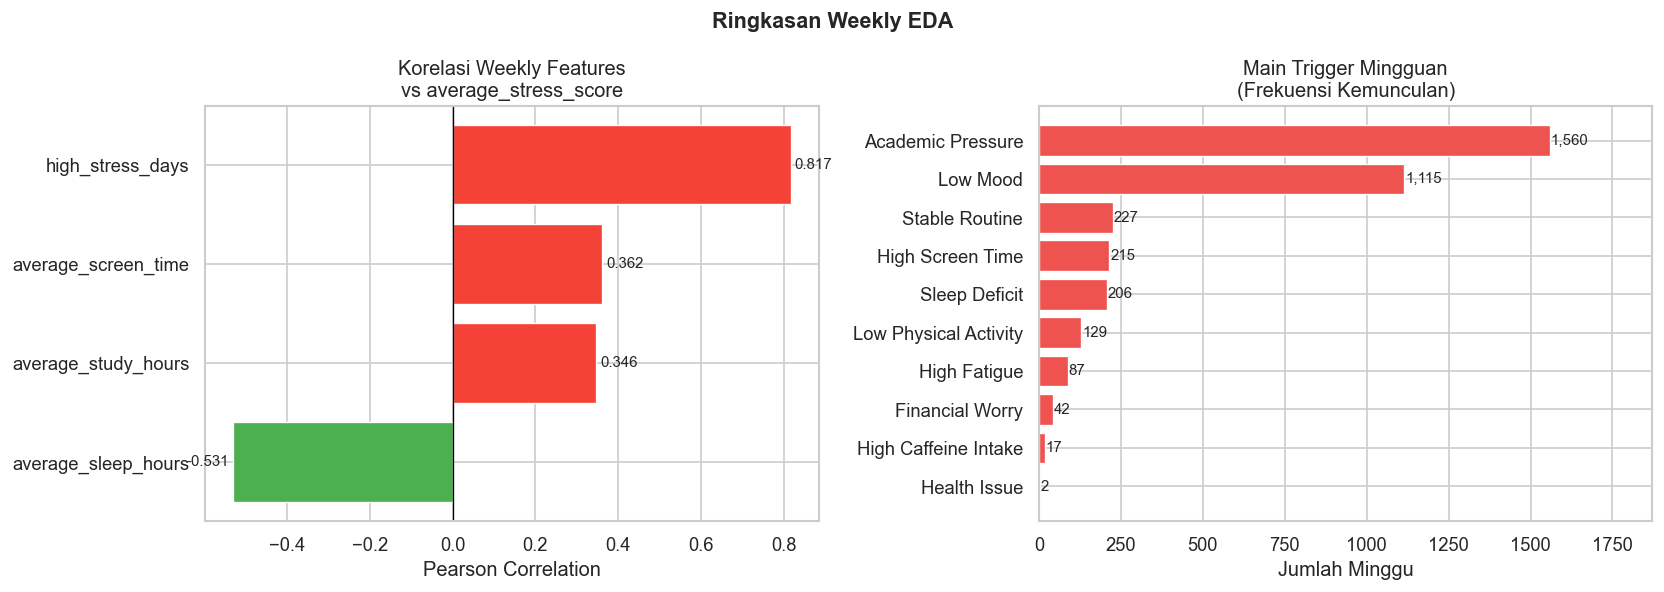

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ringkasan Weekly EDA', fontsize=13, fontweight='bold')

# --- Korelasi weekly features ---
weekly_corr_sorted = weekly_corr.sort_values('pearson_corr')
colors_w = ['#4CAF50' if v < 0 else '#F44336' for v in weekly_corr_sorted['pearson_corr']]
axes[0].barh(weekly_corr_sorted['feature'], weekly_corr_sorted['pearson_corr'],
             color=colors_w, edgecolor='white', linewidth=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Korelasi Weekly Features\nvs average_stress_score')
axes[0].set_xlabel('Pearson Correlation')
for i, (_, row) in enumerate(weekly_corr_sorted.iterrows()):
    offset = 0.01 if row['pearson_corr'] >= 0 else -0.01
    ha = 'left' if row['pearson_corr'] >= 0 else 'right'
    axes[0].text(row['pearson_corr'] + offset, i, f'{row["pearson_corr"]:.3f}',
                 va='center', ha=ha, fontsize=9)

# --- Main trigger weekly ---
# Bersihkan format weekly_trigger
wt = weekly_trigger.copy()
wt.columns = ['trigger', 'count']
wt = wt[wt['trigger'] != 'count'].copy()
wt['count'] = pd.to_numeric(wt['count'], errors='coerce')
wt = wt.dropna().sort_values('count')

axes[1].barh(wt['trigger'], wt['count'], color='#EF5350', edgecolor='white', linewidth=0.8)
axes[1].set_title('Main Trigger Mingguan\n(Frekuensi Kemunculan)')
axes[1].set_xlabel('Jumlah Minggu')
for i, (_, row) in enumerate(wt.iterrows()):
    axes[1].text(row['count'] + 2, i, f'{int(row["count"]):,}', va='center', ha='left', fontsize=9)
axes[1].set_xlim(0, wt['count'].max() * 1.2)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + '15_summary_weekly_eda.png', bbox_inches='tight')
plt.show()

## Insight 
- `high_stress_days` adalah fitur mingguan terkuat dengan korelasi 0.817 terhadap `average_stress_score`, jauh di atas fitur lainnya.
- `average_sleep_hours` satu-satunya fitur dengan korelasi negatif (-0.531), konsisten dengan temuan daily EDA.
- `average_screen_time` (0.362) dan `average_study_hours` (0.346) berkorelasi positif tapi moderat, pola ini selaras dengan daily EDA.
- Academic Pressure mendominasi trigger mingguan dengan 1.560 kemunculan, hampir 40% lebih banyak dari trigger kedua Low Mood (1.115).
- Sleep Deficit hanya muncul 206 kali sebagai main trigger mingguan, jauh lebih rendah dari ekspektasi mengingat `sleep_hours` adalah fitur kuat di daily EDA. Ini wajar karena trigger mingguan dipilih berdasarkan yang paling dominan per minggu, bukan akumulasi.

# 4. Ringkasan Insight Recommendation Output EDA (03_recommendation_output_eda)

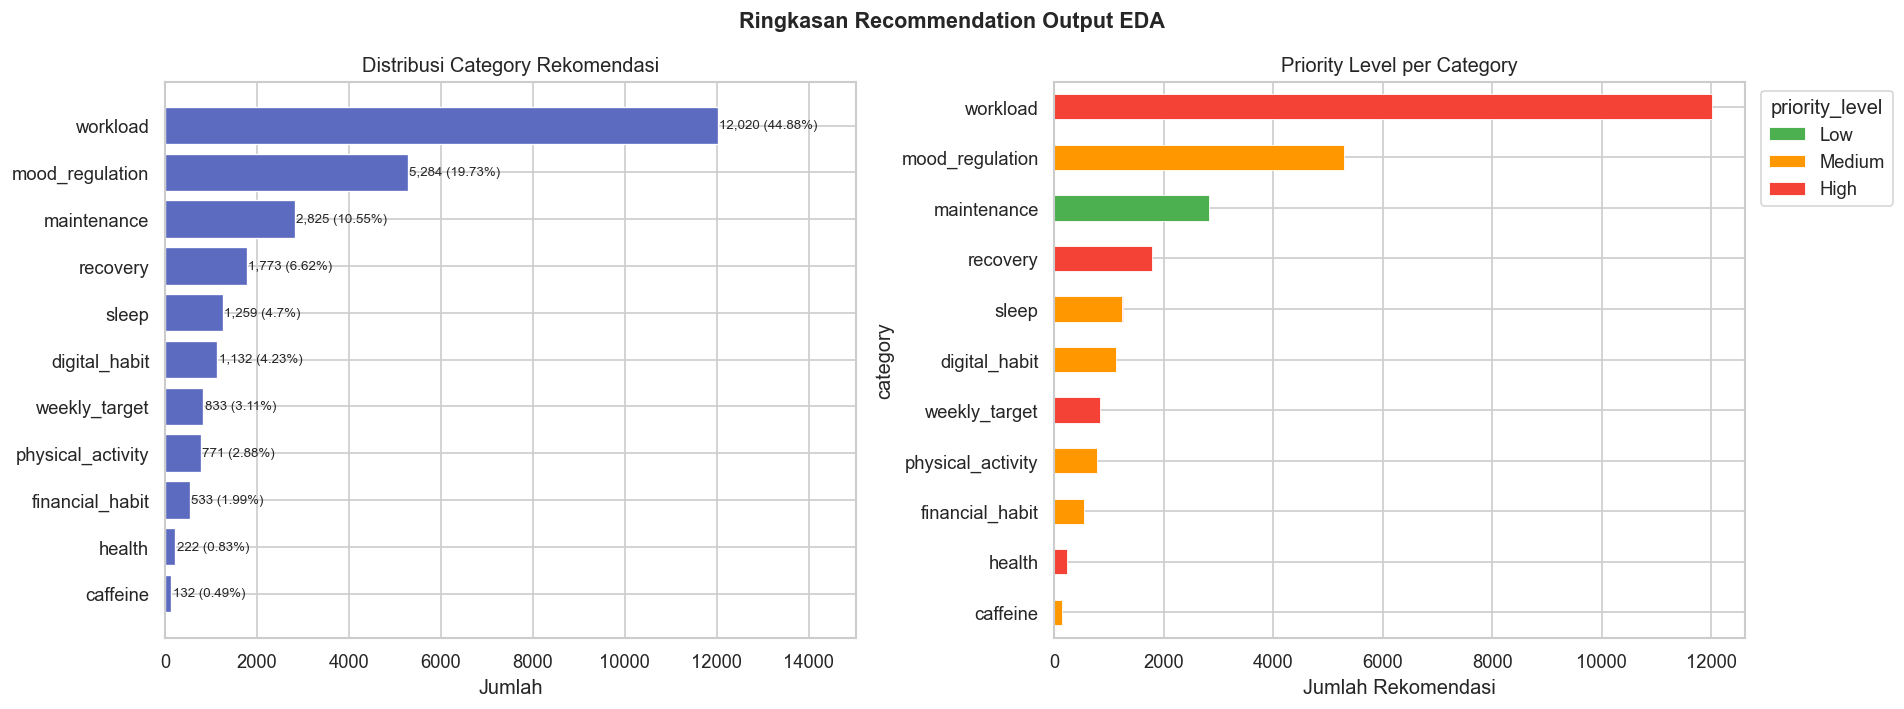

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ringkasan Recommendation Output EDA', fontsize=13, fontweight='bold')

PRIORITY_PALETTE = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}

# --- Category distribution ---
rec_cat_sorted = rec_category.sort_values('count')
axes[0].barh(rec_cat_sorted['category'], rec_cat_sorted['count'],
             color='#5C6BC0', edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribusi Category Rekomendasi')
axes[0].set_xlabel('Jumlah')
for i, (_, row) in enumerate(rec_cat_sorted.iterrows()):
    axes[0].text(row['count'] + 30, i, f'{row["count"]:,} ({row["pct"]}%)',
                 va='center', ha='left', fontsize=8)
axes[0].set_xlim(0, rec_cat_sorted['count'].max() * 1.25)

# --- Category by priority stacked ---
rec_pri = rec_priority.set_index('category')
pri_cols = [c for c in ['Low', 'Medium', 'High'] if c in rec_pri.columns]
rec_pri = rec_pri[pri_cols]
rec_pri['total'] = rec_pri.sum(axis=1)
rec_pri = rec_pri.sort_values('total').drop(columns='total')

rec_pri.plot(kind='barh', stacked=True, ax=axes[1],
             color=[PRIORITY_PALETTE[p] for p in pri_cols],
             edgecolor='white', linewidth=0.5)
axes[1].set_title('Priority Level per Category')
axes[1].set_xlabel('Jumlah Rekomendasi')
axes[1].legend(title='priority_level', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + '16_summary_recommendation_eda.png', bbox_inches='tight')
plt.show()

## Insight 
- `workload` mendominasi distribusi rekomendasi dengan 12.020 kemunculan (44.88%),  hampir separuh dari seluruh output sistem, dan seluruhnya berpriority High.
- `mood_regulation` di posisi kedua (5.284 / 19.73%) dengan priority Medium, selaras dengan `mood_score` sebagai fitur negatif terkuat di daily EDA.
- `maintenance` adalah satu-satunya category dengan priority Low, artinya sistem hanya memberi rekomendasi ringan saat kondisi mahasiswa relatif stabil.
- `caffeine` dan `health` muncul paling jarang (132 dan 222),  konsisten dengan korelasi kedua fitur tersebut yang rendah di daily EDA.
- Tidak ada anomali distribusi, setiap category hanya punya satu priority level, sesuai rule yang didefinisikan. Output sistem sudah konsisten dan siap dipakai sebagai referensi rule-based recommendation.

# 5. Feature Engineering Plan

In [8]:
fe_plan = pd.DataFrame([
    {
        'feature_baru'         : 'social_media_ratio',
        'formula'              : 'social_media_hours / screen_time_hours',
        'alasan'               : 'Proporsi screen time untuk sosmed — lebih informatif dari nilai absolut',
        'basis_eda'            : 'social_media_hours korelasi rendah jika berdiri sendiri'
    },
    {
        'feature_baru'         : 'study_screen_balance',
        'formula'              : 'study_hours / (screen_time_hours + 1)',
        'alasan'               : 'Rasio produktivitas vs konsumsi layar',
        'basis_eda'            : 'screen_time positif, study_hours juga positif terhadap stress — kombinasinya menarik'
    },
    {
        'feature_baru'         : 'academic_pressure_index',
        'formula'              : '(assignment_load + deadline_pressure) / 2',
        'alasan'               : 'Gabungan dua fitur akademik teratas menjadi satu indeks tekanan',
        'basis_eda'            : 'deadline_pressure & assignment_load top 2 korelasi & importance'
    },
    {
        'feature_baru'         : 'recovery_index',
        'formula'              : '(sleep_hours * mood_score) / (fatigue_level + 1)',
        'alasan'               : 'Indeks pemulihan — gabungan tidur, mood, dan kelelahan',
        'basis_eda'            : 'Ketiganya masuk top fitur; pola recovery jelas di boxplot per stress_level'
    },
    {
        'feature_baru'         : 'digital_pressure_index',
        'formula'              : 'screen_time_hours + social_media_hours',
        'alasan'               : 'Total paparan layar harian sebagai satu dimensi',
        'basis_eda'            : 'Keduanya bergerak searah terhadap stress'
    },
    {
        'feature_baru'         : 'emotional_pressure_index',
        'formula'              : 'fatigue_level + (10 - mood_score)',
        'alasan'               : 'Tekanan emosional gabungan — fatigue tinggi + mood rendah = beban emosional tinggi',
        'basis_eda'            : 'fatigue & mood dua fitur paling kuat, arahnya berlawanan'
    },
    {
        'feature_baru'         : 'sleep_category',
        'formula'              : "bins: <6='kurang', 6-8='cukup', >8='lebih'",
        'alasan'               : 'Kategorisasi tidur sesuai threshold risk di rule stress_score',
        'basis_eda'            : 'Risk rule: tidur <6 jam = risiko tinggi, 7-8 jam = risiko rendah'
    },
    {
        'feature_baru'         : 'activity_level',
        'formula'              : "bins: <15='rendah', 15-45='sedang', >45='tinggi'",
        'alasan'               : 'Kategorisasi aktivitas fisik sesuai threshold trigger rule',
        'basis_eda'            : 'Trigger: physical_activity_minutes < 15 = Low Physical Activity'
    },
    {
        'feature_baru'         : 'caffeine_category',
        'formula'              : "bins: <=200='normal', 200-350='tinggi', >350='sangat_tinggi'",
        'alasan'               : 'Kategorisasi kafein sesuai threshold risk dan trigger rule',
        'basis_eda'            : 'Risk: >200mg naik; Trigger: >350mg = High Caffeine Intake'
    },
])

print('=== Candidate Feature Engineering ===\n')
fe_plan[['feature_baru', 'formula', 'alasan', 'basis_eda']]

=== Candidate Feature Engineering ===



,feature_baru,formula,alasan,basis_eda
0,social_media_ratio,social_media_hours / screen_time_hours,Proporsi screen time untuk sosmed — lebih info...,social_media_hours korelasi rendah jika berdir...
1,study_screen_balance,study_hours / (screen_time_hours + 1),Rasio produktivitas vs konsumsi layar,"screen_time positif, study_hours juga positif ..."
2,academic_pressure_index,(assignment_load + deadline_pressure) / 2,Gabungan dua fitur akademik teratas menjadi sa...,deadline_pressure & assignment_load top 2 kore...
3,recovery_index,(sleep_hours * mood_score) / (fatigue_level + 1),"Indeks pemulihan — gabungan tidur, mood, dan k...",Ketiganya masuk top fitur; pola recovery jelas...
4,digital_pressure_index,screen_time_hours + social_media_hours,Total paparan layar harian sebagai satu dimensi,Keduanya bergerak searah terhadap stress
5,emotional_pressure_index,fatigue_level + (10 - mood_score),Tekanan emosional gabungan — fatigue tinggi + ...,"fatigue & mood dua fitur paling kuat, arahnya ..."
6,sleep_category,"bins: <6='kurang', 6-8='cukup', >8='lebih'",Kategorisasi tidur sesuai threshold risk di ru...,"Risk rule: tidur <6 jam = risiko tinggi, 7-8 j..."
7,activity_level,"bins: <15='rendah', 15-45='sedang', >45='tinggi'",Kategorisasi aktivitas fisik sesuai threshold ...,Trigger: physical_activity_minutes < 15 = Low ...
8,caffeine_category,"bins: <=200='normal', 200-350='tinggi', >350='...",Kategorisasi kafein sesuai threshold risk dan ...,Risk: >200mg naik; Trigger: >350mg = High Caff...


In [9]:
# save 
fe_plan.to_csv(OUTPUT_REPORTS + 'feature_engineering_plan_from_eda.csv', index=False)
print('Saved: feature_engineering_plan_from_eda.csv')

Saved: feature_engineering_plan_from_eda.csv


# 6. Kolom yang Dikeluarkan dari Modelling

In [10]:
excluded = pd.DataFrame([
    {'kolom': 'id',                  'tabel_asal': 'daily_activities',   'alasan': 'Primary key — identifier teknis, bukan fitur'},
    {'kolom': 'user_id',             'tabel_asal': 'daily_activities',   'alasan': 'Foreign key — identifier teknis, bukan fitur'},
    {'kolom': 'activity_id',         'tabel_asal': 'stress_predictions', 'alasan': 'Foreign key — identifier teknis'},
    {'kolom': 'activity_date',       'tabel_asal': 'daily_activities',   'alasan': 'Timestamp — tidak relevan sebagai fitur tanpa feature engineering waktu'},
    {'kolom': 'created_at',          'tabel_asal': 'daily_activities',   'alasan': 'Timestamp teknis'},
    {'kolom': 'updated_at',          'tabel_asal': 'daily_activities',   'alasan': 'Timestamp teknis'},
    {'kolom': 'stress_score',        'tabel_asal': 'stress_predictions', 'alasan': 'DATA LEAKAGE — stress_score adalah basis pembentukan stress_level'},
    {'kolom': 'recommendation_text', 'tabel_asal': 'recommendations',    'alasan': 'Output sistem — bukan fitur input'},
    {'kolom': 'insight_text',        'tabel_asal': 'insights',           'alasan': 'Output sistem — bukan fitur input'},
    {'kolom': 'weekly_summary_id',   'tabel_asal': 'recommendations',    'alasan': 'Foreign key — identifier teknis'},
    {'kolom': 'stress_prediction_id','tabel_asal': 'recommendations',    'alasan': 'Foreign key — identifier teknis'},
])

print('=== Kolom yang Dikeluarkan dari Modelling ===\n')
excluded

=== Kolom yang Dikeluarkan dari Modelling ===



,kolom,tabel_asal,alasan
0,id,daily_activities,"Primary key — identifier teknis, bukan fitur"
1,user_id,daily_activities,"Foreign key — identifier teknis, bukan fitur"
2,activity_id,stress_predictions,Foreign key — identifier teknis
3,activity_date,daily_activities,Timestamp — tidak relevan sebagai fitur tanpa ...
4,created_at,daily_activities,Timestamp teknis
5,updated_at,daily_activities,Timestamp teknis
6,stress_score,stress_predictions,DATA LEAKAGE — stress_score adalah basis pembe...
7,recommendation_text,recommendations,Output sistem — bukan fitur input
8,insight_text,insights,Output sistem — bukan fitur input
9,weekly_summary_id,recommendations,Foreign key — identifier teknis


In [11]:
excluded.to_csv(OUTPUT_REPORTS + 'excluded_columns_for_modelling.csv', index=False)
print('Saved: excluded_columns_for_modelling.csv')

Saved: excluded_columns_for_modelling.csv


# 7. Struktur Final Modelling Dataset

In [12]:
original_features = [
    'sleep_hours', 'study_hours', 'screen_time_hours', 'social_media_hours',
    'physical_activity_minutes', 'caffeine_intake_mg', 'mood_score',
    'fatigue_level', 'assignment_load', 'deadline_pressure',
    'social_interaction_score', 'financial_worry_score', 'health_condition_score'
]

engineered_features = [fe['feature_baru'] for _, fe in fe_plan.iterrows()]

modelling_structure = pd.DataFrame(
    [(f, 'original', 'numerik') for f in original_features] +
    [(f, 'engineered', 'numerik/kategori') for f in engineered_features] +
    [('stress_level', 'target', 'Low / Medium / High')]
    , columns=['kolom', 'tipe', 'format']
)

print('=== Struktur Final Modelling Dataset ===')
print(f'Total fitur original  : {len(original_features)}')
print(f'Total fitur engineered: {len(engineered_features)}')
print(f'Target                : stress_level\n')
modelling_structure

=== Struktur Final Modelling Dataset ===
Total fitur original  : 13
Total fitur engineered: 9
Target                : stress_level



,kolom,tipe,format
0,sleep_hours,original,numerik
1,study_hours,original,numerik
2,screen_time_hours,original,numerik
3,social_media_hours,original,numerik
4,physical_activity_minutes,original,numerik
5,caffeine_intake_mg,original,numerik
6,mood_score,original,numerik
7,fatigue_level,original,numerik
8,assignment_load,original,numerik
9,deadline_pressure,original,numerik


In [13]:
#save

modelling_structure.to_csv(OUTPUT_REPORTS + 'modelling_dataset_structure.csv', index=False)
print('Saved: modelling_dataset_structure.csv')

print('\n=== Semua output notebook 04 telah disimpan ===')
print('  outputs/reports/feature_engineering_plan_from_eda.csv')
print('  outputs/reports/excluded_columns_for_modelling.csv')
print('  outputs/reports/modelling_dataset_structure.csv')
print('  outputs/figures/eda/14_summary_daily_corr_vs_importance.png')
print('  outputs/figures/eda/15_summary_weekly_eda.png')
print('  outputs/figures/eda/16_summary_recommendation_eda.png')

Saved: modelling_dataset_structure.csv

=== Semua output notebook 04 telah disimpan ===
  outputs/reports/feature_engineering_plan_from_eda.csv
  outputs/reports/excluded_columns_for_modelling.csv
  outputs/reports/modelling_dataset_structure.csv
  outputs/figures/eda/14_summary_daily_corr_vs_importance.png
  outputs/figures/eda/15_summary_weekly_eda.png
  outputs/figures/eda/16_summary_recommendation_eda.png


# 8. Kesimpulan dan Keputusan 


- Dari 13 fitur original `daily_activities`, semua dipertahankan, tidak ada yang dihapus.
- 5 fitur terkuat berdasarkan korelasi dan importance: `fatigue_level` (0.632, 0.1448), `deadline_pressure` (0.591, 0.1359), `sleep_hours` (-0.270, 0.1338), `assignment_load` (0.463, 0.0746), `mood_score` (-0.519, 0.0726).
- `social_media_hours` adalah fitur terlemah (korelasi 0.027) — dipertahankan hanya dalam bentuk `social_media_ratio`.
- 9 fitur engineered ditambahkan, total fitur masuk modelling: 22 fitur + 1 target (`stress_level`).
- `stress_score` wajib dikeluarkan, data leakage karena merupakan basis pembentukan `stress_level`.
- 10 kolom lain dikeluarkan: identifier teknis, timestamp, dan output sistem.
- Saat mengeksekusi `social_media_ratio` di notebook berikutnya, tambahkan guard division by zero pada `screen_time_hours`.